# Combined Correlation Analysis Per Video: Pose + MoLab vs IRAF SAT (n=10)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

FEATURES_DIR = '../data/processed/features/'
OUT_DIR      = '../data/processed/features/combined/per_video/'
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
pose  = pd.read_csv(FEATURES_DIR + 'pose/per_video/correlation_results.csv').assign(source='Pose')
molab = pd.read_csv(FEATURES_DIR + 'molab/per_video/molab_correlation_results.csv').assign(source='MoLab')

combined = pd.concat([pose, molab], ignore_index=True)
combined.to_csv(OUT_DIR + 'combined_correlation_results.csv', index=False)
print(f'Pose: {len(pose)} rows, MoLab: {len(molab)} rows, Combined: {len(combined)} rows')


Pose: 120 rows, MoLab: 80 rows, Combined: 200 rows


In [3]:
top = (combined
    .assign(abs_rho=combined['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
    .drop(columns='abs_rho')
    .head(20)
    .reset_index(drop=True))
top


,feature,iraf_score,spearman_rho,p_value,source
0,forb_trunk_hip_correlation,iraf_rörelsestart,0.779246,0.007883,Pose
1,forb_trunk_hip_correlation,iraf_total,0.769697,0.009222,Pose
2,mean_R_knee_flexion,iraf_utgångsposition,-0.745455,0.013330,MoLab
3,forb_trunk_hip_correlation,iraf_utgångsposition,0.721212,0.018573,Pose
4,delta_pelvis_tilt,iraf_utgångsposition,0.709091,0.021666,MoLab
5,forb_peak_pelvis_gyro,iraf_rörelseutförande,0.684848,0.028883,MoLab
6,peak_pelvis_gyro,iraf_rörelseutförande,0.684848,0.028883,MoLab
7,forb_rms_trunk_acceleration,iraf_rörelseutförande,0.672727,0.033041,Pose
8,forb_peak_pelvis_gyro,iraf_utgångsposition,0.672727,0.033041,MoLab
9,peak_pelvis_gyro,iraf_utgångsposition,0.672727,0.033041,MoLab


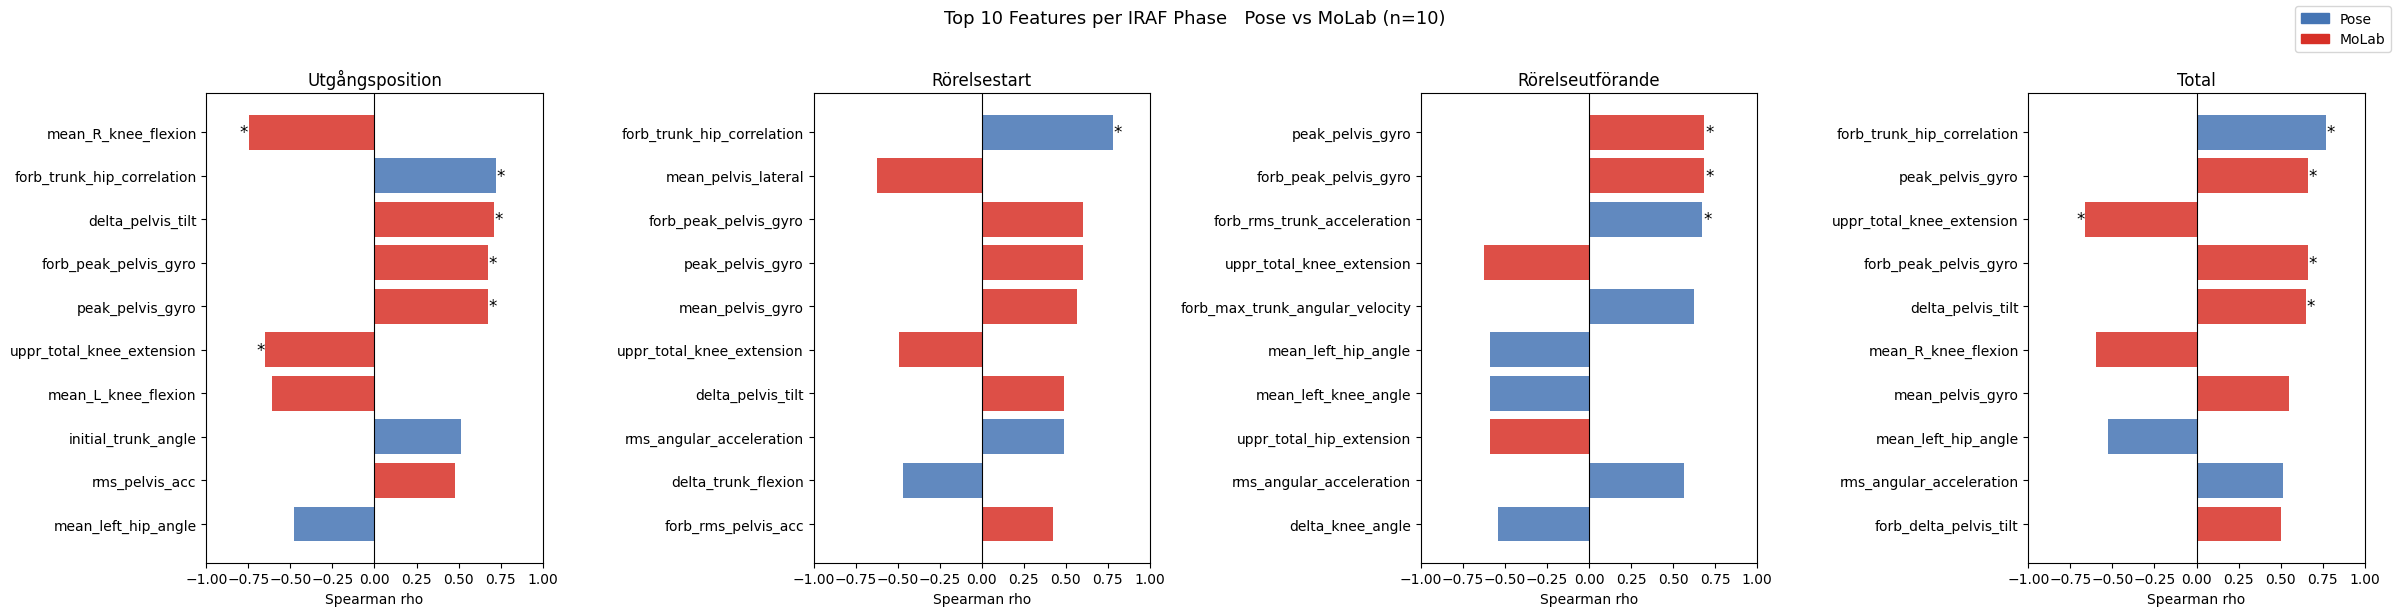

In [4]:
iraf_order = ['iraf_utgångsposition', 'iraf_rörelsestart', 'iraf_rörelseutförande', 'iraf_total']
iraf_titles = ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande', 'Total']

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, ic, title in zip(axes, iraf_order, iraf_titles):
    sub = combined[combined['iraf_score'] == ic].copy()
    sub = sub.assign(abs_rho=sub['spearman_rho'].abs()).sort_values('abs_rho', ascending=False).head(10)
    colors = ['#4575b4' if s == 'Pose' else '#d73027' for s in sub['source']]
    ax.barh(sub['feature'], sub['spearman_rho'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(sub.iterrows()):
        if row['p_value'] < 0.05:
            ax.text(row['spearman_rho'] + (0.03 if row['spearman_rho'] >= 0 else -0.03),
                    i, '*', ha='center', va='center', fontsize=12)

from matplotlib.patches import Patch
legend = [Patch(color='#4575b4', label='Pose'), Patch(color='#d73027', label='MoLab')]
fig.legend(handles=legend, loc='upper right', fontsize=10)
plt.suptitle('Top 10 Features per IRAF Phase   Pose vs MoLab (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + 'combined_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()


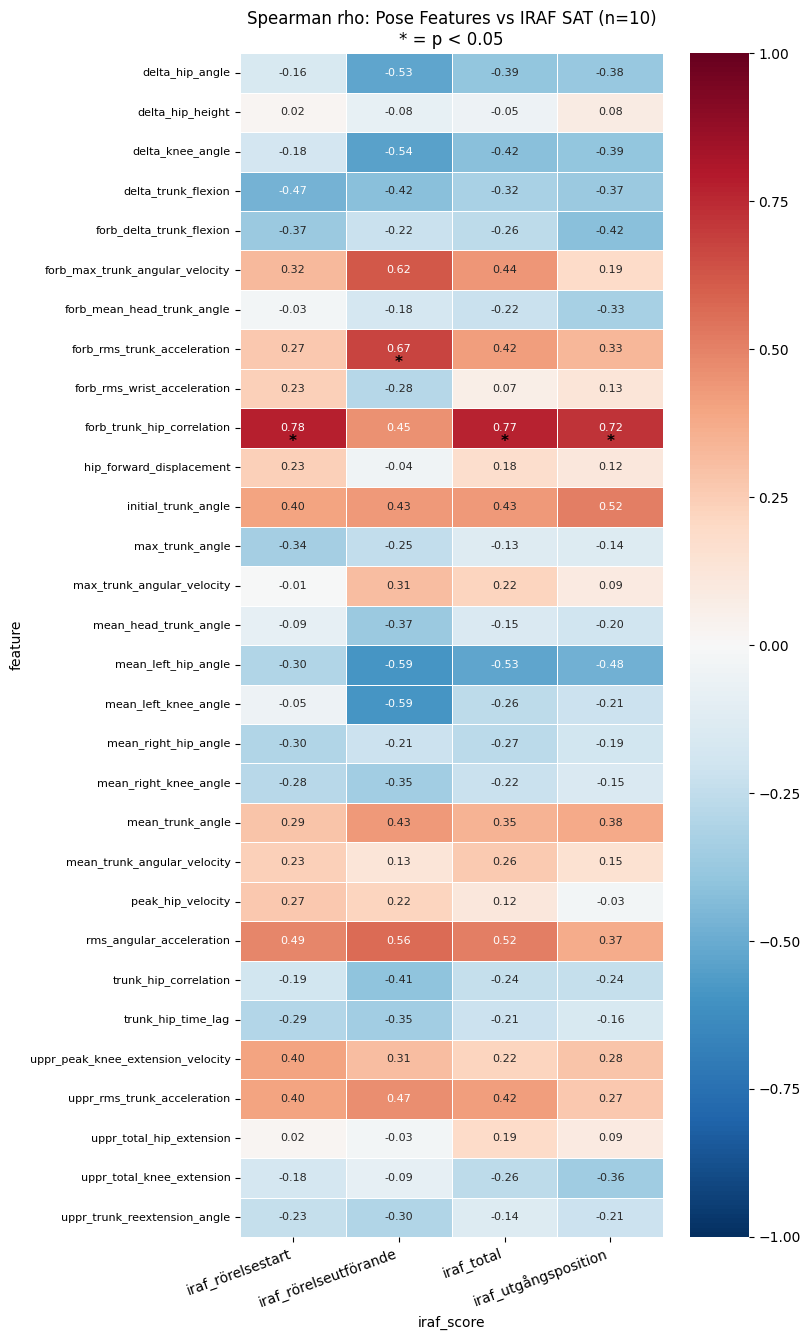

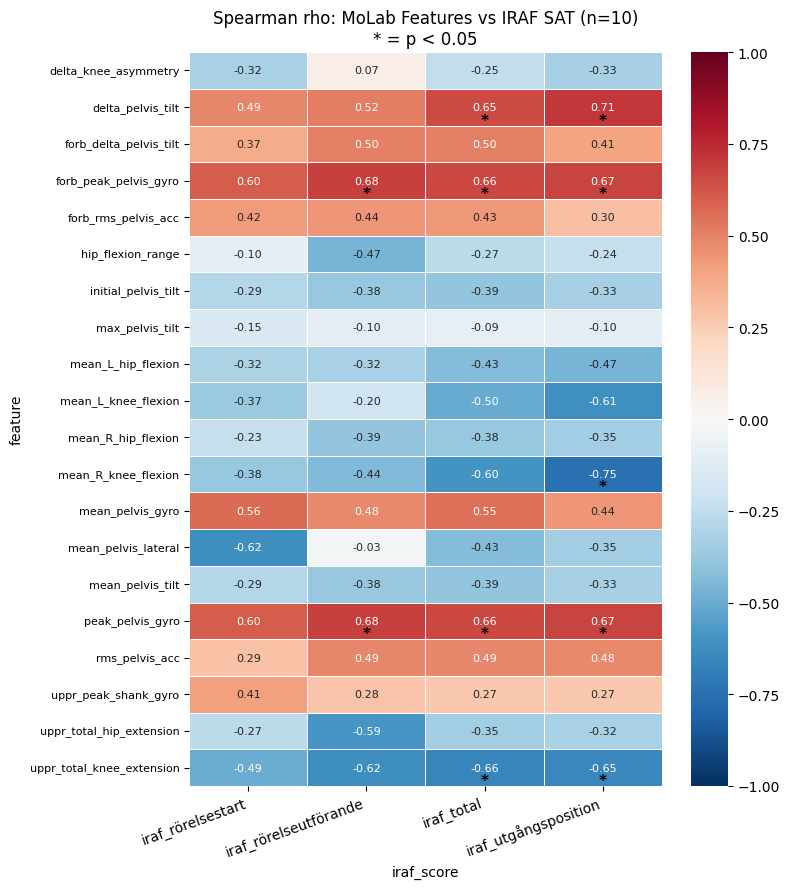

In [5]:
for source_name, df_src in [('Pose', pose), ('MoLab', molab)]:
    pivot   = df_src.pivot_table(index='feature', columns='iraf_score', values='spearman_rho')
    p_pivot = df_src.pivot_table(index='feature', columns='iraf_score', values='p_value')

    fig, ax = plt.subplots(figsize=(8, max(6, len(pivot) * 0.45)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
                ax=ax, linewidths=0.5, mask=pivot.isna(), annot_kws={'size': 8})
    for i, feat in enumerate(pivot.index):
        for j, ic in enumerate(pivot.columns):
            if pd.notna(p_pivot.loc[feat, ic]) and p_pivot.loc[feat, ic] < 0.05:
                ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Spearman rho: {source_name} Features vs IRAF SAT (n=10)\n* = p < 0.05', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR + f'combined_{source_name.lower()}_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


### Feature selection: |rho| >= 0.63 and p < 0.05
**Max 5 Pose + 5 MoLab per phase** 

In [6]:
RHO_THRESHOLD  = 0.63
P_THRESHOLD    = 0.05
MAX_PER_SOURCE = 5
MIN_PER_SOURCE = 3

def select_features(df):
    result = []
    for (iraf_col, source), group in df.groupby(['iraf_score', 'source']):
        group = group.sort_values('spearman_rho', key=abs, ascending=False)
        passing = group[
            (group['spearman_rho'].abs() >= RHO_THRESHOLD) &
            (group['p_value'] < P_THRESHOLD)
        ]
        selected = passing.head(MAX_PER_SOURCE)
        if len(selected) < MIN_PER_SOURCE:
            selected = group.head(max(MIN_PER_SOURCE, len(selected)))
        result.append(selected)
    return pd.concat(result).reset_index(drop=True)

selected_top = select_features(combined)

selected_top.to_csv(OUT_DIR + 'selected_features.csv', index=False)
print(f"Total selected: {len(selected_top)} | saved: selected_features.csv")

phase_map = {
    'iraf_utgångsposition': 'selected_features_init.csv',
    'iraf_rörelsestart':    'selected_features_start.csv',
    'iraf_rörelseutförande':'selected_features_execution.csv',
    'iraf_total':           'selected_features_total.csv',
}
for iraf_col, fname in phase_map.items():
    sub = selected_top[selected_top['iraf_score'] == iraf_col]
    sub.to_csv(OUT_DIR + fname, index=False)
    print(f"  {fname}: {len(sub)} features ({sub['source'].value_counts().to_dict()})")

Total selected: 27 | saved: selected_features.csv
  selected_features_init.csv: 8 features ({'MoLab': 5, 'Pose': 3})
  selected_features_start.csv: 6 features ({'MoLab': 3, 'Pose': 3})
  selected_features_execution.csv: 6 features ({'MoLab': 3, 'Pose': 3})
  selected_features_total.csv: 7 features ({'MoLab': 4, 'Pose': 3})


## Stående till sittande (Stand-to-Sit)

In [7]:
DOWN_POSE_DIR  = '../data/processed/features_down/pose/per_video/'
DOWN_MOLAB_DIR = '../data/processed/features_down/molab/per_video/'
DOWN_OUT_DIR   = '../data/processed/features_down/combined/per_video/'
os.makedirs(DOWN_OUT_DIR, exist_ok=True)

pose_d  = pd.read_csv(DOWN_POSE_DIR  + 'correlation_results.csv').assign(source='Pose')
molab_d = pd.read_csv(DOWN_MOLAB_DIR + 'molab_correlation_results.csv').assign(source='MoLab')

combined_d = pd.concat([pose_d, molab_d], ignore_index=True)
combined_d.to_csv(DOWN_OUT_DIR + 'combined_correlation_results.csv', index=False)
print(f'Pose: {len(pose_d)} rows, MoLab: {len(molab_d)} rows, Combined: {len(combined_d)} rows')


Pose: 176 rows, MoLab: 108 rows, Combined: 284 rows


In [8]:
top_d = (combined_d
    .assign(abs_rho=combined_d['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
    .drop(columns='abs_rho')
    .head(20)
    .reset_index(drop=True))
top_d


,feature,iraf_score,spearman_rho,p_value,source
0,fas2_pelvis_lateral,iraf_total,-0.769697,0.009222,MoLab
1,fas1_pelvis_lateral,iraf_total,-0.757576,0.011143,MoLab
2,stance_to_hip_ratio,iraf_utgångsposition,-0.757576,0.011143,Pose
3,initial_trunk_angle,iraf_rörelseutförande,0.725623,0.017528,Pose
4,fas2_rms_pelvis_acc,iraf_rörelseutförande,0.719526,0.018984,MoLab
5,fas2_pelvis_lateral,iraf_rörelsestart,-0.713624,0.020471,MoLab
6,mean_trunk_angle,iraf_rörelseutförande,0.695135,0.025647,Pose
7,fas2_pelvis_backward_displacement,iraf_rörelseutförande,0.664647,0.036028,Pose
8,fas1_peak_thigh_gyro,iraf_utgångsposition,-0.660606,0.037588,MoLab
9,stance_width,iraf_utgångsposition,-0.648485,0.042540,Pose


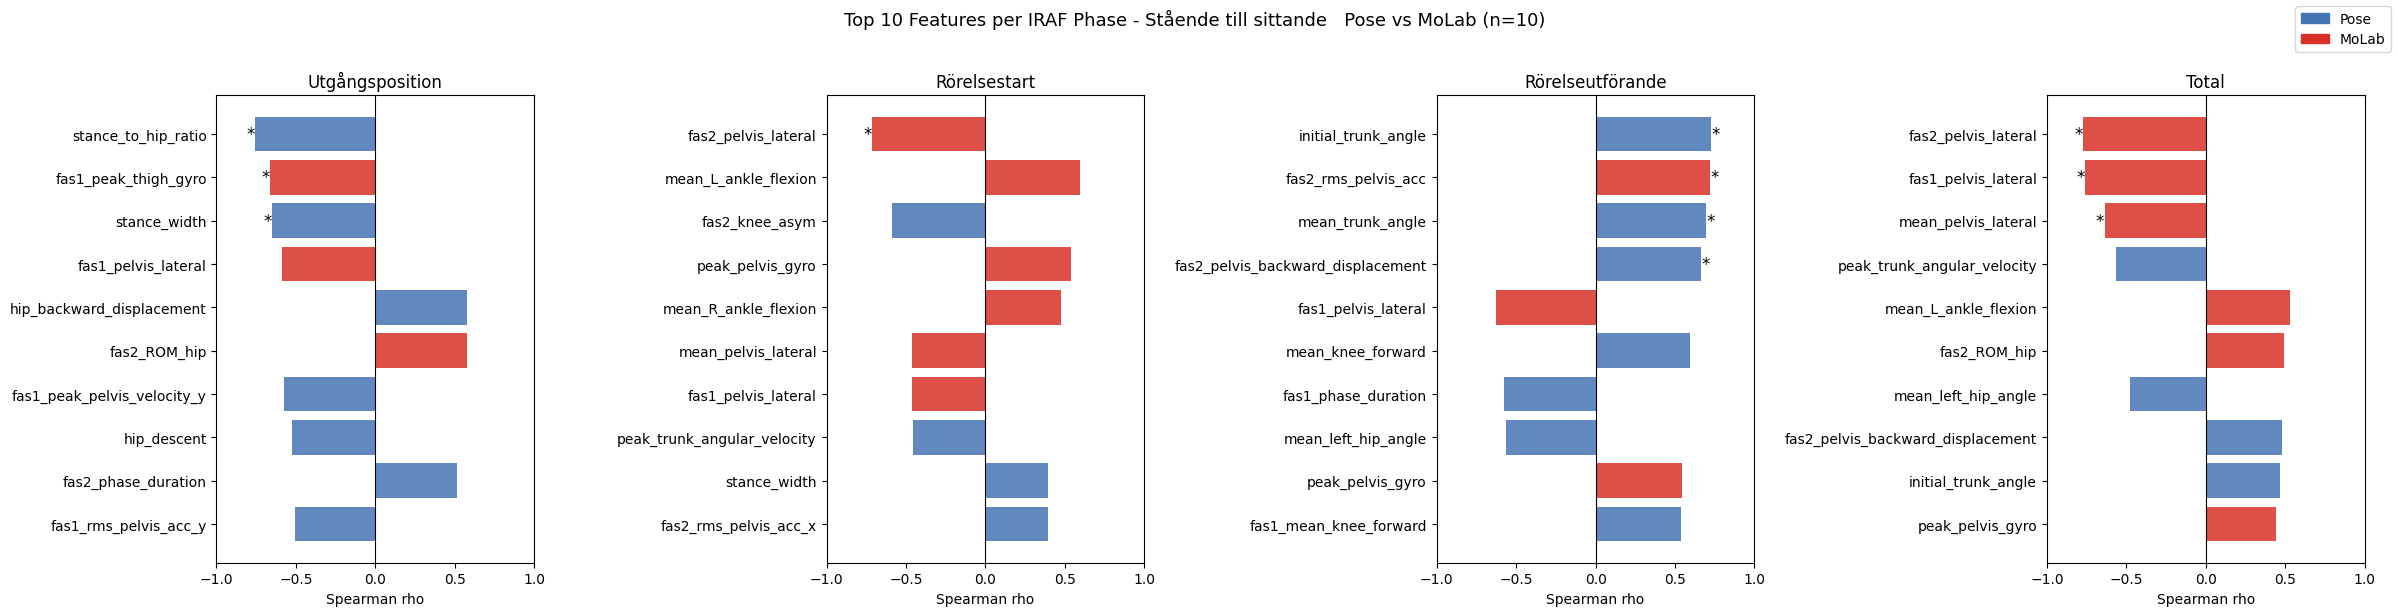

In [9]:
iraf_order = ['iraf_utgångsposition', 'iraf_rörelsestart', 'iraf_rörelseutförande', 'iraf_total']
iraf_titles = ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande', 'Total']

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, ic, title in zip(axes, iraf_order, iraf_titles):
    sub = combined_d[combined_d['iraf_score'] == ic].copy()
    sub = sub.assign(abs_rho=sub['spearman_rho'].abs()).sort_values('abs_rho', ascending=False).head(10)
    colors = ['#4575b4' if s == 'Pose' else '#d73027' for s in sub['source']]
    ax.barh(sub['feature'], sub['spearman_rho'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(sub.iterrows()):
        if row['p_value'] < 0.05:
            ax.text(row['spearman_rho'] + (0.03 if row['spearman_rho'] >= 0 else -0.03),
                    i, '*', ha='center', va='center', fontsize=12)

from matplotlib.patches import Patch
legend = [Patch(color='#4575b4', label='Pose'), Patch(color='#d73027', label='MoLab')]
fig.legend(handles=legend, loc='upper right', fontsize=10)
plt.suptitle('Top 10 Features per IRAF Phase - Stående till sittande   Pose vs MoLab (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOWN_OUT_DIR + 'combined_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()


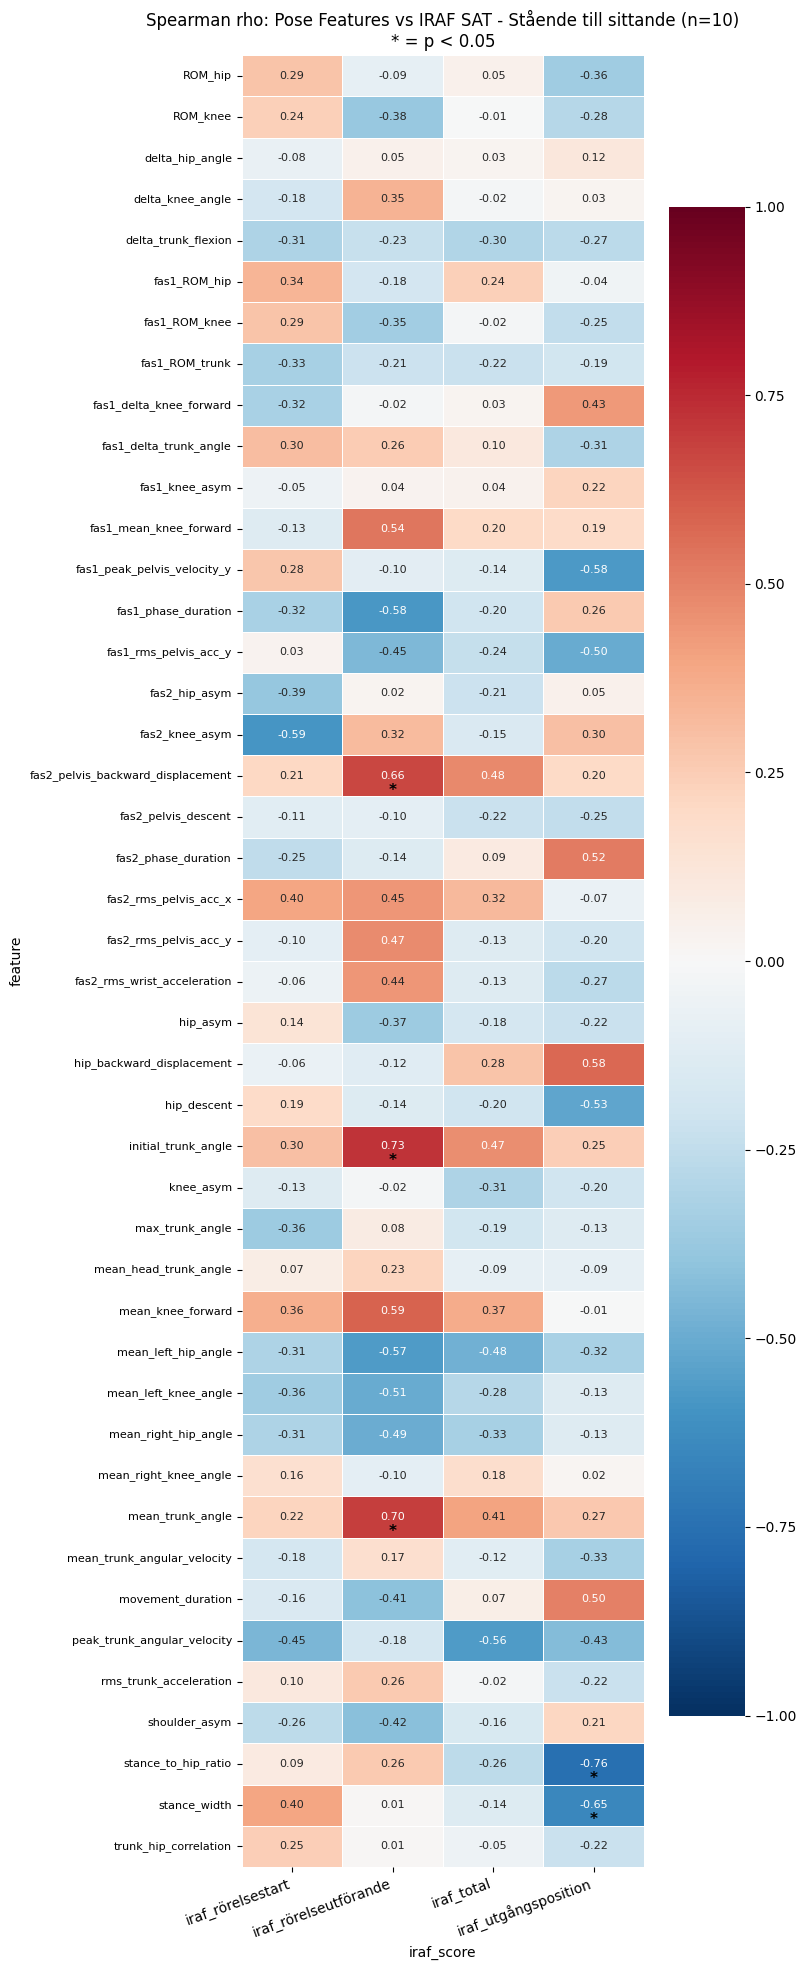

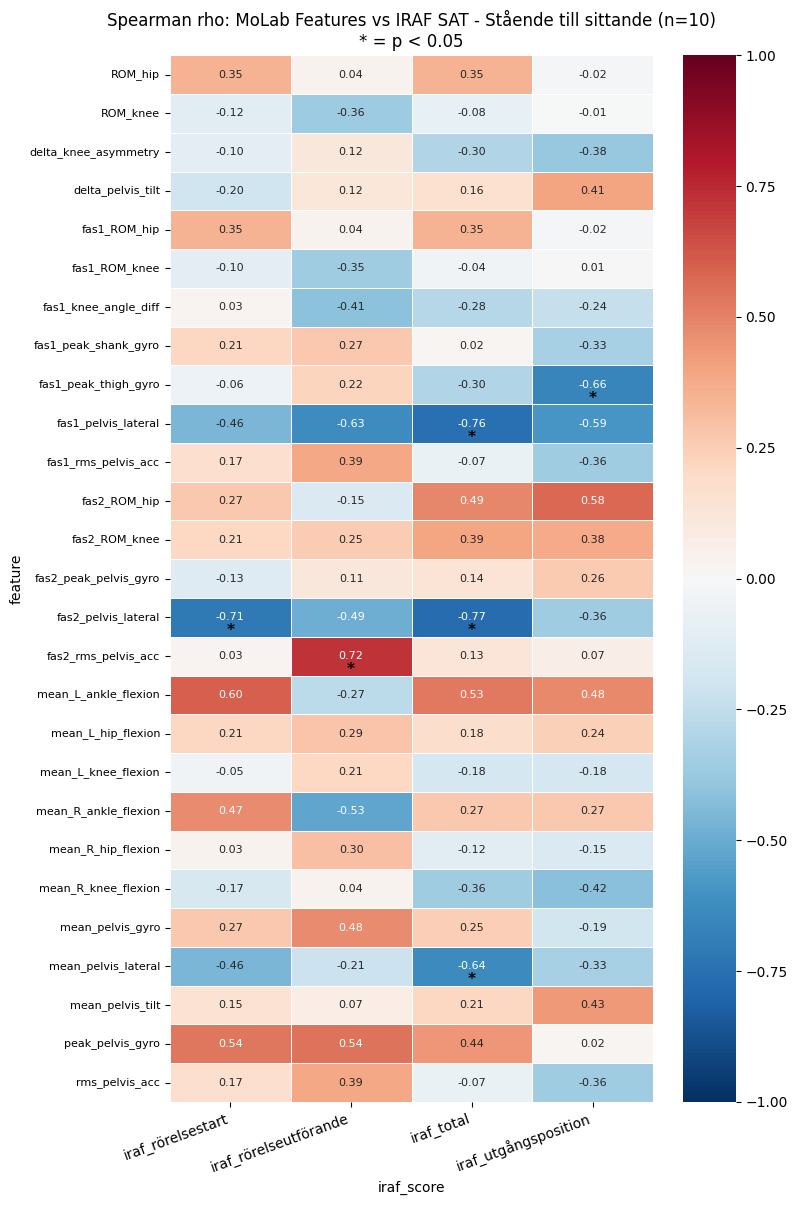

In [10]:
for source_name, df_src in [('Pose', pose_d), ('MoLab', molab_d)]:
    pivot   = df_src.pivot_table(index='feature', columns='iraf_score', values='spearman_rho')
    p_pivot = df_src.pivot_table(index='feature', columns='iraf_score', values='p_value')

    fig, ax = plt.subplots(figsize=(8, max(6, len(pivot) * 0.45)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
                ax=ax, linewidths=0.5, mask=pivot.isna(), annot_kws={'size': 8})
    for i, feat in enumerate(pivot.index):
        for j, ic in enumerate(pivot.columns):
            if pd.notna(p_pivot.loc[feat, ic]) and p_pivot.loc[feat, ic] < 0.05:
                ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Spearman rho: {source_name} Features vs IRAF SAT - Stående till sittande (n=10)\n* = p < 0.05', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(DOWN_OUT_DIR + f'combined_{source_name.lower()}_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


In [11]:
RHO_THRESHOLD  = 0.63
P_THRESHOLD    = 0.05
MAX_PER_SOURCE = 5
MIN_PER_SOURCE = 3

def select_features(df):
    result = []
    for (iraf_col, source), group in df.groupby(['iraf_score', 'source']):
        group = group.sort_values('spearman_rho', key=abs, ascending=False)
        passing = group[
            (group['spearman_rho'].abs() >= RHO_THRESHOLD) &
            (group['p_value'] < P_THRESHOLD)
        ]
        selected = passing.head(MAX_PER_SOURCE)
        if len(selected) < MIN_PER_SOURCE:
            selected = group.head(max(MIN_PER_SOURCE, len(selected)))
        result.append(selected)
    return pd.concat(result).reset_index(drop=True)

selected_top_d = select_features(combined_d)

selected_top_d.to_csv(DOWN_OUT_DIR + 'selected_features.csv', index=False)
print(f"Total selected: {len(selected_top_d)} | saved: selected_features.csv")

phase_map_d = {
    'iraf_utgångsposition': 'selected_features_init.csv',
    'iraf_rörelsestart':    'selected_features_start.csv',
    'iraf_rörelseutförande':'selected_features_execution.csv',
    'iraf_total':           'selected_features_total.csv',
}
for iraf_col, fname in phase_map_d.items():
    sub = selected_top_d[selected_top_d['iraf_score'] == iraf_col]
    sub.to_csv(DOWN_OUT_DIR + fname, index=False)
    print(f"  {fname}: {len(sub)} features ({sub['source'].value_counts().to_dict()})")


Total selected: 24 | saved: selected_features.csv
  selected_features_init.csv: 6 features ({'MoLab': 3, 'Pose': 3})
  selected_features_start.csv: 6 features ({'MoLab': 3, 'Pose': 3})
  selected_features_execution.csv: 6 features ({'MoLab': 3, 'Pose': 3})
  selected_features_total.csv: 6 features ({'MoLab': 3, 'Pose': 3})
